# Cyclical Encoding

Cyclical Encoding is a feature engineering technique used to represent
cyclical variables in a way that preserves their natural circular relationship.

Some features are cyclical because their values repeat after reaching a
certain point.

Examples:

- Hours of a day: 0 → 23 → 0
- Days of a week: Monday → Sunday → Monday
- Months: January → December → January
- Seasons: Spring → Summer → Autumn → Winter → Spring

A normal numerical representation may fail to capture this circular
relationship.

Cyclical Encoding uses sine and cosine functions to represent these
features.

## The Problem with Normal Numerical Encoding

Suppose we encode hours as:

0, 1, 2, 3, ..., 22, 23

The problem is that:

23 and 0 are actually very close in time.

However, numerically:

|23 - 0| = 23

This makes them appear very far apart.

Cyclical Encoding solves this problem by representing the values on a circle.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Hour": [0, 1, 6, 12, 18, 22, 23]
})

df

,Hour
0,0
1,1
2,6
3,12
4,18
5,22
6,23


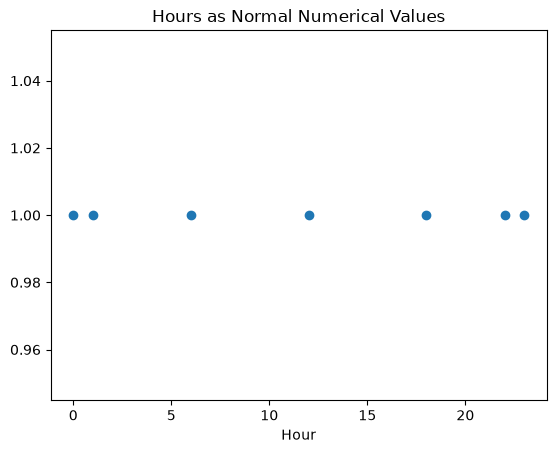

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["Hour"], [1] * len(df))

plt.xlabel("Hour")
plt.title("Hours as Normal Numerical Values")

plt.show()

## Mathematical Idea

Cyclical Encoding uses two mathematical functions:

### Sine

sin(2πx / N)

### Cosine

cos(2πx / N)

Where:

x = current value

N = total number of possible values in the cycle

For hours:

N = 24

Therefore:

Hour_Sin = sin(2π × Hour / 24)

Hour_Cos = cos(2π × Hour / 24)

In [3]:
import numpy as np

df["Hour_Sin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
)

df["Hour_Cos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
)

df

,Hour,Hour_Sin,Hour_Cos
0,0,0.000000e+00,1.000000e+00
1,1,2.588190e-01,9.659258e-01
2,6,1.000000e+00,6.123234e-17
3,12,1.224647e-16,-1.000000e+00
4,18,-1.000000e+00,-1.836970e-16
5,22,-5.000000e-01,8.660254e-01
6,23,-2.588190e-01,9.659258e-01


## Why Do We Need Both Sine and Cosine?

Using only sine or only cosine would not uniquely represent every position
in the cycle.

Using both creates a two-dimensional representation of the position on
the cycle.

The pair:

(Sin, Cos)

represents the location of the value on a circle.

This allows the model to understand that the beginning and end of the cycle
are close to each other.

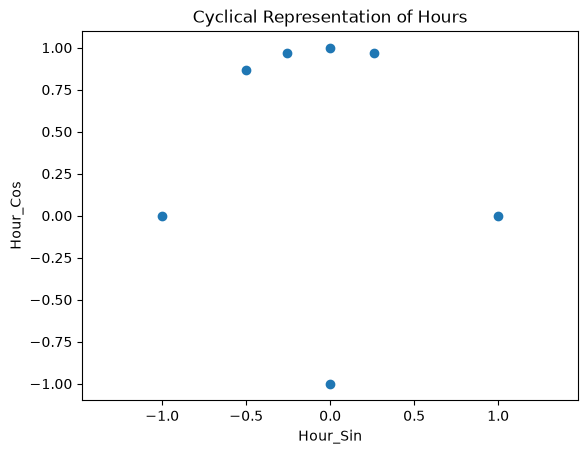

In [4]:
plt.scatter(
    df["Hour_Sin"],
    df["Hour_Cos"]
)

plt.xlabel("Hour_Sin")
plt.ylabel("Hour_Cos")
plt.title("Cyclical Representation of Hours")

plt.axis("equal")
plt.show()

## Cyclical Encoding for Day of Week

Days of the week are also cyclical.

Monday → 0
Tuesday → 1
Wednesday → 2
Thursday → 3
Friday → 4
Saturday → 5
Sunday → 6

After Sunday, the cycle returns to Monday.

Therefore:

N = 7

In [5]:
df_days = pd.DataFrame({
    "Day_of_Week": [0, 1, 2, 3, 4, 5, 6]
})

df_days["Day_Sin"] = np.sin(
    2 * np.pi * df_days["Day_of_Week"] / 7
)

df_days["Day_Cos"] = np.cos(
    2 * np.pi * df_days["Day_of_Week"] / 7
)

df_days

,Day_of_Week,Day_Sin,Day_Cos
0,0,0.000000,1.000000
1,1,0.781831,0.623490
2,2,0.974928,-0.222521
3,3,0.433884,-0.900969
4,4,-0.433884,-0.900969
5,5,-0.974928,-0.222521
6,6,-0.781831,0.623490


## Cyclical Encoding for Months

Months are cyclical:

January → February → ... → December → January

There are 12 months.

Therefore:

N = 12

We can encode the month using sine and cosine.

In [6]:
df_month = pd.DataFrame({
    "Month": range(1, 13)
})

df_month["Month_Sin"] = np.sin(
    2 * np.pi * df_month["Month"] / 12
)

df_month["Month_Cos"] = np.cos(
    2 * np.pi * df_month["Month"] / 12
)

df_month

,Month,Month_Sin,Month_Cos
0,1,5.000000e-01,8.660254e-01
1,2,8.660254e-01,5.000000e-01
2,3,1.000000e+00,6.123234e-17
3,4,8.660254e-01,-5.000000e-01
4,5,5.000000e-01,-8.660254e-01
5,6,1.224647e-16,-1.000000e+00
6,7,-5.000000e-01,-8.660254e-01
7,8,-8.660254e-01,-5.000000e-01
8,9,-1.000000e+00,-1.836970e-16
9,10,-8.660254e-01,5.000000e-01


## General Cyclical Encoding Formula

For a cyclical feature x with a cycle length N:

### Sine Encoding

x_sin = sin(2πx / N)

### Cosine Encoding

x_cos = cos(2πx / N)

The value of N depends on the cycle.

Examples:

Hour → N = 24

Day of Week → N = 7

Month → N = 12

In [7]:
df_datetime = pd.DataFrame({
    "Date": pd.to_datetime([
        "2026-01-01 00:00:00",
        "2026-01-05 08:00:00",
        "2026-02-15 12:00:00",
        "2026-03-20 18:00:00",
        "2026-04-10 23:00:00"
    ])
})

df_datetime["Hour"] = df_datetime["Date"].dt.hour
df_datetime["Day_of_Week"] = df_datetime["Date"].dt.dayofweek
df_datetime["Month"] = df_datetime["Date"].dt.month

df_datetime

,Date,Hour,Day_of_Week,Month
0,2026-01-01 00:00:00,0,3,1
1,2026-01-05 08:00:00,8,0,1
2,2026-02-15 12:00:00,12,6,2
3,2026-03-20 18:00:00,18,4,3
4,2026-04-10 23:00:00,23,4,4


In [8]:
df_datetime["Hour_Sin"] = np.sin(
    2 * np.pi * df_datetime["Hour"] / 24
)

df_datetime["Hour_Cos"] = np.cos(
    2 * np.pi * df_datetime["Hour"] / 24
)

df_datetime["Day_Sin"] = np.sin(
    2 * np.pi * df_datetime["Day_of_Week"] / 7
)

df_datetime["Day_Cos"] = np.cos(
    2 * np.pi * df_datetime["Day_of_Week"] / 7
)

df_datetime["Month_Sin"] = np.sin(
    2 * np.pi * df_datetime["Month"] / 12
)

df_datetime["Month_Cos"] = np.cos(
    2 * np.pi * df_datetime["Month"] / 12
)

df_datetime

,Date,Hour,Day_of_Week,Month,Hour_Sin,Hour_Cos,Day_Sin,Day_Cos,Month_Sin,Month_Cos
0,2026-01-01 00:00:00,0,3,1,0.000000e+00,1.000000e+00,0.433884,-0.900969,0.500000,8.660254e-01
1,2026-01-05 08:00:00,8,0,1,8.660254e-01,-5.000000e-01,0.000000,1.000000,0.500000,8.660254e-01
2,2026-02-15 12:00:00,12,6,2,1.224647e-16,-1.000000e+00,-0.781831,0.623490,0.866025,5.000000e-01
3,2026-03-20 18:00:00,18,4,3,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969,1.000000,6.123234e-17
4,2026-04-10 23:00:00,23,4,4,-2.588190e-01,9.659258e-01,-0.433884,-0.900969,0.866025,-5.000000e-01
